# Diabetes Linear Regression Example

This notebook shows a simple beginner-friendly example of linear regression using the diabetes dataset from scikit-learn. We will load the data, inspect it, split it into training and testing sets, train a model, and evaluate the results.

In [1]:
# importing libraries
import numpy as np
import pandas as pd

In [2]:
# Import the dataset from scikit-learn
from sklearn.datasets import load_diabetes

# Load the built-in diabetes dataset
diabetes = load_diabetes()

In [3]:
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

In [4]:
# Convert the dataset into a Pandas DataFrame for easier exploration
# Each column represents one feature from the diabetes dataset.
df = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)

df["target"] = diabetes.target

In [5]:
# Display the first few rows of the dataset
# This helps us quickly understand the kind of data we are working with.
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [6]:
# Display the last few rows of the dataset
df.tail()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0
441,-0.045472,-0.044642,-0.073030,-0.081413,0.083740,0.027809,0.173816,-0.039493,-0.004222,0.003064,57.0


## Explore the dataset

In this section, we look at the structure of the data and check whether any cleaning is needed before training a model.

In [7]:
# Show the dataset information, including column names and data types
# This helps us understand the structure of the data.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [8]:
# Show a summary of the numerical columns
# This gives simple statistics such as mean and standard deviation.
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [9]:
# Check for missing values in the dataset
# If there are no missing values, we do not need to clean the data for this step.
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

## Prepare the data

We now separate the features from the target variable so the model can learn from the input data.

In [10]:
# Prepare the input features and target values
# X contains the input features, and y contains the value we want to predict.
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [11]:
# Display the feature matrix
X

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [12]:
# Display the target values
y

0      151.0
1       75.0
2      141.0
3      206.0
4      135.0
       ...  
437    178.0
438    104.0
439    132.0
440    220.0
441     57.0
Name: target, Length: 442, dtype: float64

In [13]:
# Check the type of the features and target
print(type(X))
print(type(y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [14]:
# Check the shape of the features and target
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [15]:
# Split the data into training and testing sets
# Using random_state=42 makes the split consistent and easy to reproduce.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Split into train and test sets

We divide the data into two parts so the model can learn from one part and be tested on another.

In [16]:
# Check the sizes of the training and testing sets
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(353, 10)
(89, 10)
(353,)
(89,)


In [17]:
# Create a linear regression model
from sklearn.linear_model import LinearRegression

# This model learns a straight-line relationship between the input features and the target.
model = LinearRegression()

## Build the model

We use a linear regression model because this is a regression problem, where the target value is continuous.

In [18]:
# Train the model and make predictions
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate the model using simple regression metrics
# R² tells us how much of the variation in the target is explained by the model.
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)


R² Score: 0.4526027629719195


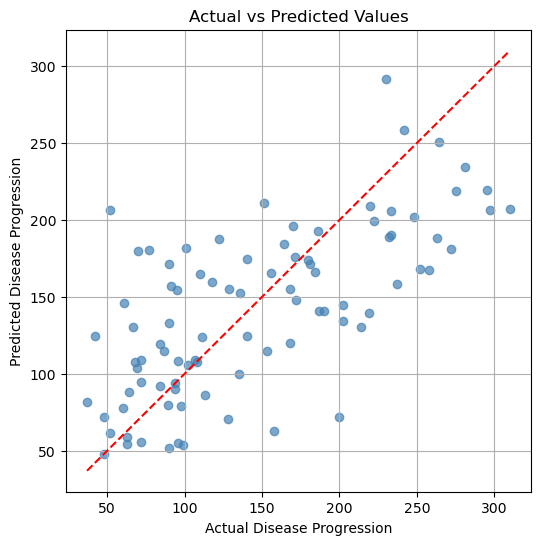

In [19]:
# Visualize the actual versus predicted values
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='steelblue')

# Add a reference line for perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--', color='red')

plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Disease Progression')
plt.ylabel('Predicted Disease Progression')
plt.grid(True)
plt.show()

Linear Regression assumes a linear relationship between the input features and the target variable. However, diabetes progression is influenced by complex and non-linear interactions among medical factors such as BMI, blood pressure, and blood serum measurements. Because of this, a simple linear model cannot capture all the underlying patterns, resulting in a relatively low R² score.

Around 45% of the variation in diabetes progression is explained by the model.

About 55% is still unexplained.

## Results 

The model has been trained and evaluated. In regression, a higher R² score means the model explains more of the variation in the target values. A lower error means the predictions are closer to the actual values.

# Conclusion

In this notebook, we built a simple Linear Regression model using the Diabetes dataset provided by scikit-learn.

### Key Takeaways
- Loaded and explored the dataset.
- Converted the data into a pandas DataFrame for easier analysis.
- Checked for missing values before training.
- Split the dataset into training and testing sets.
- Trained a Linear Regression model.
- Evaluated the model using R² Score.
- Visualized Actual vs Predicted values.

### Final Observation

The model achieved an R² Score of approximately **0.45** on the test dataset.

This indicates that the Linear Regression model explains around **45% of the variation** in the target values. While it provides a reasonable baseline, more advanced regression models or feature engineering may improve prediction performance.